## Notebook to analyze real data from Multistep genomics on single cells and live cultures in subnanoliter capsules 
https://www.science.org/doi/10.1126/science.ady7209 downloaded from GEO

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np

In [22]:
path_to_adata = "/home/gzu5140/Keerthana_b1042/grnInference/real_data/microcapsule_data/GSM9228947_K562_all_conditions.h5ad"
adata = sc.read_h5ad(path_to_adata)

In [9]:
adata_fin = adata[adata.obs["condition"].str.contains("Ctrl", na=False)]
adata_fin.obs['cell_id'].nunique()

9865

In [5]:
barcode_df = adata_fin.obs
# Convert index to Series for easy parsing
idx = barcode_df.index.to_series()

df_parsed = barcode_df.copy()
df_parsed["barcode"] = idx.str.split("-").str[0]
df_parsed["day"]     = idx.str.split("-").str[1]

df_parsed["day"] = (
    df_parsed["day"]
    .str.extract(r"(day\d+)", expand=False)
)

unique_barcodes_per_day = (
    df_parsed
    .groupby("day")["barcode"]
    .nunique()
)

print(unique_barcodes_per_day)

barcode_day_counts = (
    df_parsed
    .groupby("barcode")["day"]
    .nunique()
)

day
day2    6393
day4    1721
day6    1609
Name: barcode, dtype: int64


In [6]:
days_per_barcode = (
    df_parsed
    .groupby("barcode")["day"]
    .nunique()
)

barcode_day_distribution = (
    days_per_barcode
    .value_counts()
    .sort_index()
)

print(barcode_day_distribution)


day
1    9669
2      27
Name: count, dtype: int64


In [11]:
cells_per_barcode

barcode
bcABGQXK    1
bcABKQRC    1
bcABOUPG    1
bcABPGVM    1
bcABTOGA    1
           ..
bcGSKLNW    1
bcGSKMDF    1
bcGSKMIV    1
bcGSKOJY    1
bcGSKOKV    1
Length: 48021, dtype: int64

(array([4.8017e+04, 3.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([ 1. ,  3.1,  5.2,  7.3,  9.4, 11.5, 13.6, 15.7, 17.8, 19.9, 22. ]),
 <BarContainer object of 10 artists>)

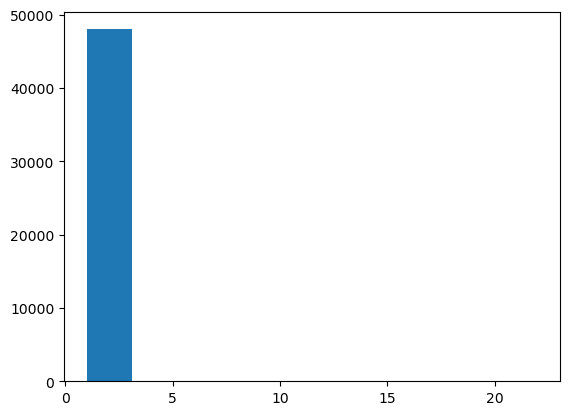

In [10]:
cells_per_barcode = df_parsed.groupby("barcode").size()
import matplotlib.pyplot as plt
plt.hist(cells_per_barcode)